In [3]:
import zipfile
with zipfile.ZipFile("archive (1).zip", "r") as zip_ref:
    zip_ref.extractall(".")
print("✅ Extracted!")

✅ Extracted!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("creditcard.csv")
print("Shape:", df.shape)
print("Fraud cases:", df["Class"].sum())
print("Fraud %:", df["Class"].mean()*100, "%")
print(df.head())

Shape: (284807, 31)
Fraud cases: 492
Fraud %: 0.1727485630620034 %
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Scale Amount
df["Amount_scaled"] = StandardScaler().fit_transform(df[["Amount"]])
df.drop(columns=["Amount","Time"], inplace=True)

X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training model... please wait ⏳")
model = RandomForestClassifier(
    n_estimators=50, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
print("✅ Model trained!")
print(classification_report(y_test, predictions))

Training model... please wait ⏳
✅ Model trained!
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.82      0.88        98

    accuracy                           1.00     56962
   macro avg       0.98      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



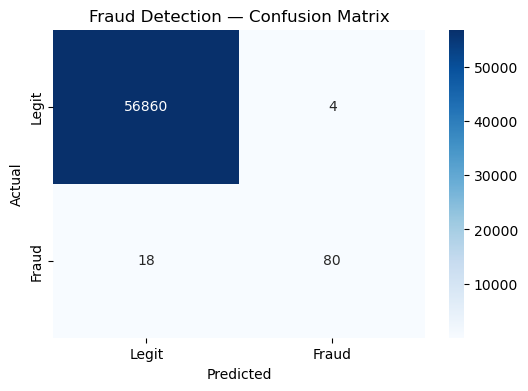

🎉 Fraud Detection Project Complete!


In [6]:
# Confusion Matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legit","Fraud"],
            yticklabels=["Legit","Fraud"])
plt.title("Fraud Detection — Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.savefig("fraud_result.png")
plt.show()
print("🎉 Fraud Detection Project Complete!")